ИР3. Проекторы

[0.01570829 0.04712098 0.07852205 0.10990375 0.14125833 0.17257805
 0.2038552  0.23508205 0.26625089 0.29735404 0.32838382 0.35933258
 0.39019268 0.4209565  0.45161646 0.48216499 0.51259456 0.54289764
 0.57306678 0.60309452 0.63297346 0.66269622 0.69225547 0.72164391
 0.7508543  0.77987943 0.80871213 0.8373453  0.86577187 0.89398481
 0.92197719 0.94974207 0.97727263 1.00456205 1.03160361 1.05839065
 1.08491654 1.11117474 1.13715878 1.16286224 1.18827878 1.21340213
 1.23822609 1.26274454 1.28695142 1.31084077 1.33440669 1.35764337
 1.38054506 1.40310613 1.425321   1.44718419 1.46869032 1.48983406
 1.51061022 1.53101365 1.55103933 1.57068231 1.58993775 1.60880089
 1.62726709 1.64533178 1.66299052 1.68023893 1.69707277 1.71348789
 1.72948022 1.74504584 1.76018089 1.77488164 1.78914446 1.80296584
 1.81634237 1.82927074 1.84174777 1.85377037 1.86533558 1.87644055
 1.88708253 1.89725891 1.90696716 1.9162049  1.92496985 1.93325983
 1.94107282 1.94840687 1.95526018 1.96163106 1.96751794 1.9729

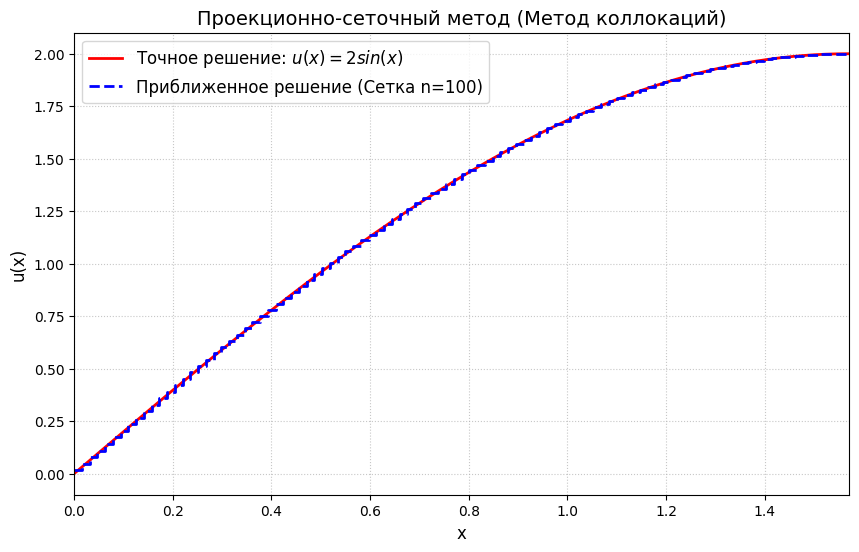

In [6]:
import numpy as np
import matplotlib.pyplot as plt


def Simpson_integrate(func, a, b, N):

    if N % 2 == 1:
        N += 1
        
    h = (b - a) / N
    x = np.linspace(a, b, N + 1)
    y = func(x)
    
    S = y[0] + y[-1] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2])
    return (h / 3.0) * S



a = 0.0
b = np.pi / 2.0
n = 100

def K(x, s):
    return np.sin(x) * np.cos(s)


def f(x):
    return np.sin(x)

# Точное решение
def u_exact(x):
    return 2.0 * np.sin(x)


x_edges = np.linspace(a, b, n + 1)
x_mid = (x_edges[:-1] + x_edges[1:]) / 2.0 


K_mat = np.zeros((n, n))
F_vec = np.zeros(n)

for j in range(n):
    F_vec[j] = f(x_mid[j])
    
    for k in range(n):
        
        integral_val = Simpson_integrate(lambda s: K(x_mid[j], s), x_edges[k], x_edges[k+1], N=100)
        K_mat[j, k] = integral_val


I = np.eye(n)
C = np.linalg.solve(I - K_mat, F_vec) 
print(C)
x_plot = np.linspace(a, b, 200)
y_exact = u_exact(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_exact, 'r-', linewidth=2, label='Точное решение: $u(x) = 2sin(x)$')

C_plot = np.append(C, C[-1])
plt.step(x_edges, C_plot, where='post', color='blue', linewidth=2, linestyle='--', 
         label=f'Приближенное решение (Сетка n={n})')

plt.title('Проекционно-сеточный метод (Метод коллокаций)', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('u(x)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.xlim(a, b)

print("\n--- ПОГРЕШНОСТЬ НА КАЖДОМ ШАГЕ (В УЗЛАХ КОЛЛОКАЦИИ) ---")
errors = []
for j in range(n):
    exact_val = u_exact(x_mid[j])
    err = np.abs(exact_val - C[j])
    errors.append(err)
    print(f"Узел {j:2d} (x = {x_mid[j]:.4f}): Точное = {exact_val:.7f}, Приближ. = {C[j]:.7f}, Погрешность = {err:.4e}")

min_error = np.min(errors)
print(f"\nИТОГОВАЯ МИН. ПОГРЕШНОСТЬ: {min_error:.4e}")

plt.show()